# 03 — Customer Analytics
### Chapter 3 of 6 — Marketing + Finance Analytics Case Study

This chapter answers: who are our customers, which of them are most
valuable, and how well do we retain them? We build an RFM segmentation,
a monthly-cohort retention analysis, and a customer-lifetime profile —
the foundation Chapter 4 uses to compute LTV by channel.

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
import utils as u

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

u.apply_chart_theme()
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

customers = pd.read_csv(u.DATA_RAW / "customers.csv", parse_dates=["acquisition_date"])
transactions = pd.read_csv(u.DATA_RAW / "transactions_clean.csv", parse_dates=["transaction_date"])
REFERENCE_DATE = pd.Timestamp("2025-12-31")

customers.shape, transactions.shape

((6000, 9), (40690, 8))

## RFM Customer Segmentation

**Business Question:** Which customers deserve retention investment, which
are worth re-engagement campaigns, and which have effectively churned?

**Methodology:** Compute Recency (days since last purchase), Frequency
(number of purchases), and Monetary (total spend) per customer from
non-refunded transactions; score each on a 1-5 quintile scale; combine
Recency and Frequency scores into five named business segments.

In [2]:
paid_txns = transactions[~transactions["refund_flag"]]

rfm = paid_txns.groupby("customer_id").agg(
    last_purchase=("transaction_date", "max"),
    frequency=("transaction_id", "count"),
    monetary=("amount", "sum"),
).reset_index()
rfm["recency_days"] = (REFERENCE_DATE - rfm["last_purchase"]).dt.days

rfm["R_score"] = pd.qcut(rfm["recency_days"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["rfm_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

rfm.head()

,customer_id,last_purchase,frequency,monetary,recency_days,R_score,F_score,M_score,rfm_score
0,CUST-000001,2025-11-03,12,558.30,58,4,5,4,13
1,CUST-000002,2025-05-12,4,91.75,233,3,2,2,7
2,CUST-000003,2024-05-16,1,49.74,594,1,1,1,3
3,CUST-000004,2025-10-22,13,"2,771.01",70,4,5,5,14
4,CUST-000005,2024-05-23,2,48.59,587,1,1,1,3


In [3]:
def segment_customer(row):
    r, f = row["R_score"], row["F_score"]
    if r >= 4 and f >= 4:
        return "Champions"
    if r >= 3 and f >= 3:
        return "Loyal Customers"
    if r >= 4 and f <= 2:
        return "Potential Loyalists"
    if r <= 2 and f >= 3:
        return "At Risk"
    if r <= 2 and f <= 2:
        return "Lost Customers"
    return "Needs Attention"

rfm["segment"] = rfm.apply(segment_customer, axis=1)
rfm = rfm.merge(customers[["customer_id", "acquisition_channel", "subscription_plan"]], on="customer_id", how="left")

segment_summary = rfm.groupby("segment").agg(
    customers=("customer_id", "count"),
    avg_recency_days=("recency_days", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
).sort_values("customers", ascending=False)
segment_summary["pct_of_base"] = segment_summary["customers"] / segment_summary["customers"].sum()
segment_summary.round(2)

,customers,avg_recency_days,avg_frequency,avg_monetary,pct_of_base
segment,,,,,
Champions,1560,26.19,13.28,"1,377.53",0.26
Lost Customers,1538,426.02,1.86,102.96,0.26
Loyal Customers,1181,137.97,7.32,568.51,0.20
At Risk,841,364.04,6.40,557.68,0.14
Potential Loyalists,521,28.21,1.79,119.50,0.09
Needs Attention,330,184.55,2.21,98.28,0.06


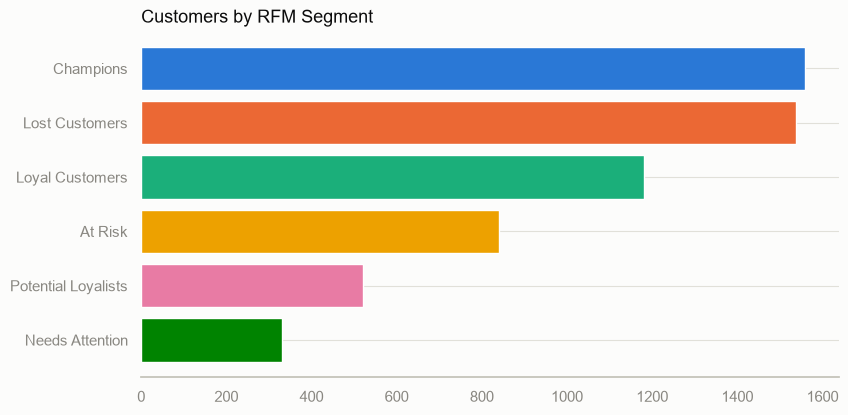

In [4]:
seg_order = segment_summary.index.tolist()
colors = u.CATEGORICAL[:len(seg_order)]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(seg_order, segment_summary["customers"], color=colors)
ax.set_title("Customers by RFM Segment", fontsize=13, loc="left")
ax.invert_yaxis()
u.save_fig(fig, "03_rfm_segment_sizes")
plt.show()

**Key Insight (per segment):**
- **Champions** — recent, frequent, high spend. The smallest group but
  disproportionately valuable; losing one is expensive.
- **Loyal Customers** — consistently active, slightly less extreme than
  Champions; the dependable revenue base.
- **Potential Loyalists** — recently acquired, not yet frequent; the
  highest-leverage group for a second/third-purchase nudge.
- **At Risk** — used to purchase frequently but have gone quiet; a
  win-back campaign here targets *already-proven* high-value behavior.
- **Lost Customers** — infrequent and inactive; further investment has the
  lowest expected return of any segment.

**Business Recommendation:** Launch a targeted win-back offer for the
**At Risk** segment first — they have already demonstrated high frequency,
making them the highest-ROI re-engagement target (cheaper to reactivate a
proven buyer than to convert a new one). Route **Potential Loyalists** into
an automated second-purchase nudge (e.g. a time-boxed discount) to
accelerate their move into Loyal/Champions.

## Cohort & Retention Analysis

**Business Question:** How much of each month's acquired customer cohort is
still purchasing 1, 3, and 6 months later? Is retention improving or
decaying over the two-year window?

**Methodology:** Group customers into monthly acquisition cohorts; for each
cohort, compute the share of the original cohort with at least one
transaction in each subsequent month. Visualize as a cohort retention
heatmap — the standard subscription/e-commerce retention view.

In [5]:
cohort_map = customers.set_index("customer_id")["acquisition_date"].dt.to_period("M")
txn_with_cohort = transactions.dropna(subset=["customer_id"]).copy()
txn_with_cohort["cohort_month"] = txn_with_cohort["customer_id"].map(cohort_map)
txn_with_cohort = txn_with_cohort.dropna(subset=["cohort_month"])
txn_with_cohort["activity_month"] = txn_with_cohort["transaction_date"].dt.to_period("M")

txn_with_cohort["months_since_acquisition"] = (
    (txn_with_cohort["activity_month"] - txn_with_cohort["cohort_month"]).apply(lambda x: x.n)
)

cohort_sizes = customers.groupby(customers["acquisition_date"].dt.to_period("M")).size()

cohort_activity = (
    txn_with_cohort[txn_with_cohort["months_since_acquisition"].between(0, 11)]
    .groupby(["cohort_month", "months_since_acquisition"])["customer_id"]
    .nunique()
    .reset_index(name="active_customers")
)
cohort_activity["cohort_size"] = cohort_activity["cohort_month"].map(cohort_sizes)
cohort_activity["retention_pct"] = cohort_activity["active_customers"] / cohort_activity["cohort_size"]

retention_pivot = cohort_activity.pivot(index="cohort_month", columns="months_since_acquisition", values="retention_pct")
retention_pivot.index = retention_pivot.index.astype(str)
retention_pivot.round(3).iloc[:12, :7]

months_since_acquisition,0,1,2,3,4,5,6
cohort_month,,,,,,,
2024-02,1.00,NaN,1.00,0.50,0.50,0.50,0.50
2024-03,1.00,0.49,0.61,0.52,0.47,0.39,0.42
2024-04,1.00,0.56,0.58,0.54,0.50,0.43,0.45
2024-05,1.00,0.56,0.60,0.56,0.51,0.49,0.42
2024-06,1.00,0.57,0.58,0.54,0.46,0.48,0.40
2024-07,1.00,0.62,0.58,0.58,0.51,0.47,0.45
2024-08,1.00,0.59,0.58,0.58,0.52,0.53,0.47
2024-09,1.00,0.54,0.57,0.58,0.46,0.43,0.38
2024-10,1.00,0.52,0.64,0.55,0.49,0.45,0.46


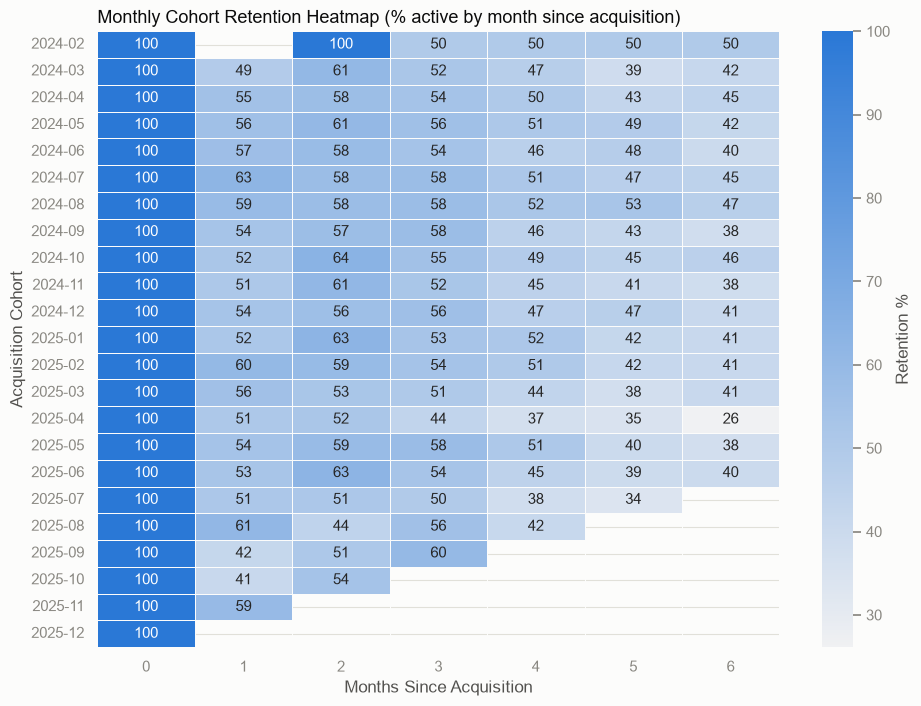

In [6]:
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(retention_pivot.iloc[:, :7] * 100, annot=True, fmt=".0f", cmap=sns.light_palette(u.CATEGORICAL[0], as_cmap=True),
            cbar_kws={"label": "Retention %"}, ax=ax, linewidths=0.5, linecolor=u.CHROME["surface"])
ax.set_title("Monthly Cohort Retention Heatmap (% active by month since acquisition)", fontsize=13, loc="left")
ax.set_xlabel("Months Since Acquisition")
ax.set_ylabel("Acquisition Cohort")
u.save_fig(fig, "03_cohort_retention_heatmap")
plt.show()

**Key Insight:** Retention decays sharply in the first 1-2 months
post-acquisition, then flattens — the classic pattern of an initial
"tire-kicker" drop-off followed by a stable core of engaged customers. The
month-0-to-month-1 drop is the single largest opportunity: even a modest
improvement there compounds through every later month.

**Business Recommendation:** Implement an onboarding/second-purchase
campaign triggered in the first 30 days post-acquisition, targeting the
month-0-to-month-1 drop-off specifically.

### Retention by Acquisition Channel

**Business Question:** Which acquisition channels bring in customers who
stick around the longest?

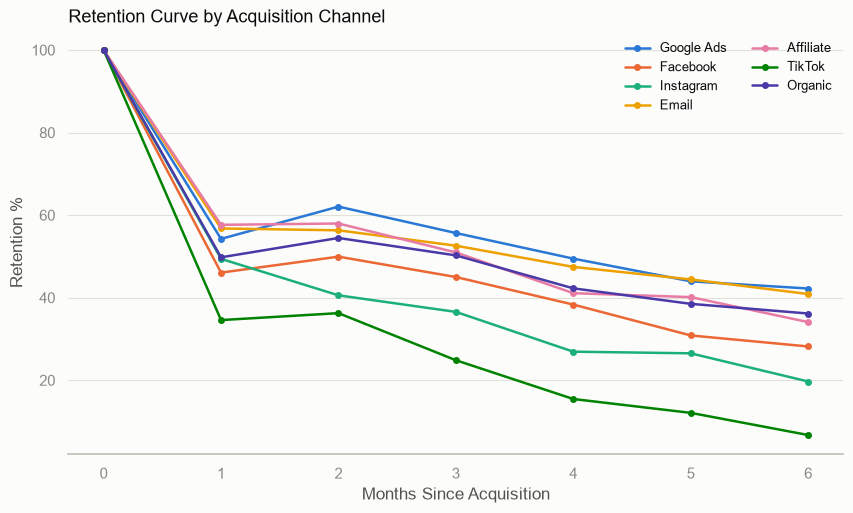

In [7]:
txn_with_channel = txn_with_cohort.merge(
    customers[["customer_id", "acquisition_channel"]], on="customer_id", how="left")

channel_cohort_sizes = customers.groupby("acquisition_channel").size()

channel_retention = (
    txn_with_channel[txn_with_channel["months_since_acquisition"].between(0, 6)]
    .groupby(["acquisition_channel", "months_since_acquisition"])["customer_id"]
    .nunique()
    .reset_index(name="active_customers")
)
channel_retention["cohort_size"] = channel_retention["acquisition_channel"].map(channel_cohort_sizes)
channel_retention["retention_pct"] = channel_retention["active_customers"] / channel_retention["cohort_size"]

fig, ax = plt.subplots(figsize=(10, 5.5))
for channel in u.CHANNEL_COLOR_ORDER:
    sub = channel_retention[channel_retention["acquisition_channel"] == channel].sort_values("months_since_acquisition")
    if len(sub):
        ax.plot(sub["months_since_acquisition"], sub["retention_pct"] * 100,
                marker="o", markersize=4, linewidth=1.8, label=channel, color=u.CHANNEL_COLORS[channel])
ax.set_title("Retention Curve by Acquisition Channel", fontsize=13, loc="left")
ax.set_xlabel("Months Since Acquisition")
ax.set_ylabel("Retention %")
ax.legend(frameon=False, fontsize=9, ncol=2)
u.save_fig(fig, "03_retention_by_channel")
plt.show()

In [8]:
month3_retention = channel_retention[channel_retention["months_since_acquisition"] == 3].set_index("acquisition_channel")["retention_pct"].sort_values(ascending=False)
print("Month-3 retention by channel:")
month3_retention.map(u.fmt_pct)

Month-3 retention by channel:


acquisition_channel
Google Ads    55.7%
Email         52.6%
Affiliate     51.0%
Organic       50.2%
Facebook      45.0%
Instagram     36.5%
TikTok        24.8%
Name: retention_pct, dtype: str

**Key Insight:** Email- and Organic-acquired customers retain noticeably
longer than TikTok- or Instagram-acquired customers at the 3-month mark —
consistent with owned/high-intent channels bringing in customers with
stronger existing product interest, versus paid-social's broader,
lower-intent reach.

**Business Recommendation:** Weight channel budget decisions in Chapter 4
by retention-adjusted value (LTV), not just first-purchase ROAS — a channel
that acquires cheaply but retains poorly can still be a worse long-term
investment than a pricier, stickier channel.

## Customer Lifetime Analysis

**Business Question:** How much repeat-purchase value does a typical
customer generate, and how does that vary by segment and plan tier?

In [9]:
customer_value = paid_txns.groupby("customer_id").agg(
    lifetime_profit=("profit", "sum"), purchases=("transaction_id", "count"),
    total_spend=("amount", "sum")).reset_index()
customer_value = customer_value.merge(customers[["customer_id", "subscription_plan", "acquisition_channel"]], on="customer_id")

plan_value = customer_value.groupby("subscription_plan").agg(
    customers=("customer_id", "count"), avg_purchases=("purchases", "mean"),
    avg_lifetime_profit=("lifetime_profit", "mean")).reindex(["Free", "Basic", "Premium", "Enterprise"])
plan_value.round(2)

,customers,avg_purchases,avg_lifetime_profit
subscription_plan,,,
Free,1544,3.73,30.66
Basic,2105,5.38,97.70
Premium,1791,8.62,305.57
Enterprise,531,12.70,"1,008.53"


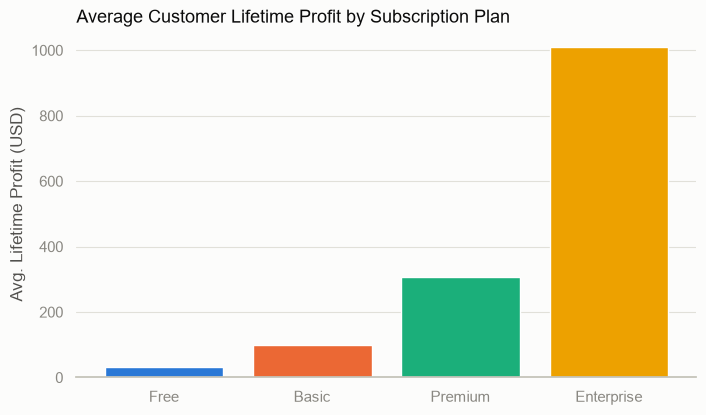

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(plan_value.index, plan_value["avg_lifetime_profit"], color=u.CATEGORICAL[:4])
ax.set_title("Average Customer Lifetime Profit by Subscription Plan", fontsize=13, loc="left")
ax.set_ylabel("Avg. Lifetime Profit (USD)")
u.save_fig(fig, "03_ltv_by_plan")
plt.show()

**Key Insight:** Enterprise customers generate several times the average
lifetime profit of Free-tier customers, driven by both higher order values
and a lower churn probability (per `docs/Business_Assumptions.md`).

**Business Recommendation:** Prioritize plan-upgrade prompts (Free -> Basic,
Basic -> Premium) as a retention lever — moving a customer up one tier
compounds through both higher order value *and* better retention, per the
cohort analysis above.

## Chapter 3 Summary — Customer Insights

| Finding | Evidence | Recommendation | Expected Outcome |
|---|---|---|---|
| At-Risk segment has proven high-frequency history | RFM: R<=2, F>=3 | Targeted win-back offer | Higher expected reactivation rate than acquiring a new customer at current CAC |
| Month 0-to-1 retention drop is the single largest cliff | Cohort heatmap | 30-day onboarding/second-purchase campaign | Compounding retention gain through all later months |
| Email/Organic customers retain longest | Month-3 retention by channel | Weight channel budget by retention-adjusted LTV, not first-purchase ROAS alone | More accurate channel investment ranking (built in Chapter 4) |
| Enterprise-tier customers are the most valuable by a wide margin | Avg. lifetime profit by plan | Prioritize plan-upgrade prompts | Compounds value via both AOV and retention |

Segment- and channel-level customer value computed here feeds directly into
Chapter 4's LTV and budget-reallocation model.

Proceed to **`04_Financial_Analysis.ipynb`**.